# 05 Advanced Models

Objective: evaluate XGBoost as the Week 7 advanced Gradient Boosting model for `ClosePrice` prediction while preserving the Week 6 preprocessing, outlier handling, and time-based validation/test design.

This notebook follows the final Week 7 workflow:
- Compare two strong Week 6 feature-set candidates for XGBoost on the May 2026 validation month.
- Compare raw `ClosePrice` against `log1p(ClosePrice)` across all five rolling validation folds.
- Select the target transform by rolling MdAPE and then tune XGBoost on the May 2026 validation month.
- Check stability on earlier historical cutoffs.
- Evaluate the final tuned model once on the June 2026 test set.
- Save final-test predictions for both raw and log1p target versions under the same selected hyperparameters.
- Compare against the prior Linear Regression, Decision Tree, and Random Forest results.
- Leave detailed segment-level evaluation for `06_evaluation.ipynb`.


## 0. Setup

In [27]:
from pathlib import Path
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "idx-california-price-prediction",
]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / "data" / "processed").exists() and (root / "notebooks").exists()
)
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
ENGINEERED_DATA_DIR = PROCESSED_DATA_DIR / "week6_feature_engineering"
ENGINEERED_SPLIT_DIR = ENGINEERED_DATA_DIR / "splits"
SPLIT_PLAN_CSV = PROCESSED_DATA_DIR / "crmls_week3_split_plan.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "week7_advanced_models"
MODEL_DIR = PROJECT_ROOT / "models" / "week7_advanced_models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

ENGINEERED_CSV = ENGINEERED_DATA_DIR / "crmls_week6_engineered.csv"
FINAL_TRAIN_CSV = ENGINEERED_SPLIT_DIR / "final_train_fixed_window_engineered.csv"
TEST_CSV = ENGINEERED_SPLIT_DIR / "test_latest_month_engineered.csv"
MODEL_PATH = MODEL_DIR / "xgboost_tuned_pipeline.joblib"

RANDOM_STATE = 42
TARGET = "ClosePrice"
VALIDATION_MONTH = "2026-05"
FEATURE_SET_NAME = None

required_files = [ENGINEERED_CSV, FINAL_TRAIN_CSV, TEST_CSV, SPLIT_PLAN_CSV]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError("Missing required Week 6 files: " + ", ".join(str(path) for path in missing_files))

print(f"Project root: {PROJECT_ROOT}")
print(f"XGBoost version: {xgb.__version__}")
print(f"Week 6 engineered data: {ENGINEERED_CSV}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Model path: {MODEL_PATH}")

Project root: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction
XGBoost version: 3.3.0
Week 6 engineered data: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/data/processed/week6_feature_engineering/crmls_week6_engineered.csv
Output directory: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week7_advanced_models
Model path: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/models/week7_advanced_models/xgboost_tuned_pipeline.joblib


## 1. Load Data and Candidate Feature Sets

Use the Week 6 engineered dataset and preserve the Week 6 preprocessing pattern: median imputation for numeric fields, missing-category imputation plus one-hot encoding for categorical fields, high-cardinality category grouping, and no numeric scaling for tree-based models.

XGBoost evaluates two Week 6 feature-set candidates before tuning:
- `Base + UnifiedSchoolDistrict`
- `Base + Structural Derived + UnifiedSchoolDistrict`


In [28]:
CATEGORICAL_DTYPE_COLS = [
    "City",
    "CountyOrParish",
    "PostalCode",
    "MLSAreaMajor",
    "Levels",
    "HighSchoolDistrict",
    "UnifiedSchoolDistrict",
]


def normalize_categorical_dtypes(df):
    for col in CATEGORICAL_DTYPE_COLS:
        if col in df.columns:
            df[col] = df[col].astype("string").fillna("__missing__")
    return df


def load_split_file(path):
    df = normalize_categorical_dtypes(pd.read_csv(path, low_memory=False))
    if "CloseDate" in df.columns:
        df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
    if "close_month" in df.columns:
        df["close_month"] = pd.PeriodIndex(df["close_month"], freq="M")
    return df


def load_engineered_data(path=ENGINEERED_CSV):
    return load_split_file(path)


def available(columns, df):
    return [col for col in columns if col in df.columns]

split_plan = pd.read_csv(SPLIT_PLAN_CSV, dtype={"split_type": "string", "eval_month": "string"})
historical_plan = (
    split_plan[split_plan["split_type"] == "historical_eval"]
    .copy()
    .sort_values("eval_month")
)
final_plan = split_plan[split_plan["split_type"] == "final_test"].copy().iloc[0]
fixed_train_window_months = int(final_plan["train_window_months"])

engineered_df = load_engineered_data()
final_train_raw = load_split_file(FINAL_TRAIN_CSV)
final_test_raw = load_split_file(TEST_CSV)

print(f"Engineered data shape: {engineered_df.shape}")
print(f"Final train shape: {final_train_raw.shape}")
print(f"Final test shape: {final_test_raw.shape}")
print(f"Historical cutoffs: {historical_plan['eval_month'].astype(str).tolist()}")

Engineered data shape: (333060, 84)
Final train shape: (130114, 83)
Final test shape: (12858, 83)
Historical cutoffs: ['2025-09', '2025-11', '2026-01', '2026-03', '2026-05']


In [29]:
LOCATION_QUALITY_FLAG_COLS = [
    "Latitude_missing",
    "Longitude_missing",
    "invalid_coordinates_flag",
    "PostalCode_format_issue_flag",
]

base_numeric_cols = [
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "AssociationFee",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
    "Flooring_material_count",
]
structural_model_numeric_cols = [
    "PropertyAgeYears",
    "BedBathRatio",
    "LivingAreaPerBedroom",
    "LogLotToLivingAreaRatio",
]
base_structural_numeric_cols = [col for col in base_numeric_cols if col != "YearBuilt"] + structural_model_numeric_cols

base_boolean_cols = [
    "ViewYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN",
    "Flooring_Carpet",
    "Flooring_Tile",
    "Flooring_Wood",
    "Flooring_Laminate",
    "Flooring_Vinyl",
    "Flooring_Stone",
    "Flooring_Concrete",
    "Flooring_Bamboo",
    "Flooring_Brick",
    "Flooring_SeeRemarks",
    "Flooring_multiple_materials_flag",
]
structural_derived_flag_cols = ["HasGarage"]

base_categorical_cols = [
    "City",
    "CountyOrParish",
    "PostalCode",
    "MLSAreaMajor",
    "Levels",
    "HighSchoolDistrict",
]
school_categorical_cols = ["UnifiedSchoolDistrict"]

base_flag_cols = [
    col for col in engineered_df.columns
    if (col.endswith("_missing") or col == "invalid_coordinates_flag")
    and col not in LOCATION_QUALITY_FLAG_COLS
]

XGBOOST_FEATURE_SET_CANDIDATES = {
    "Base + UnifiedSchoolDistrict": {
        "numeric": base_numeric_cols,
        "categorical": base_categorical_cols + school_categorical_cols,
        "boolean": base_boolean_cols,
        "flag": base_flag_cols,
    },
    "Base + Structural Derived + UnifiedSchoolDistrict": {
        "numeric": base_structural_numeric_cols,
        "categorical": base_categorical_cols + school_categorical_cols,
        "boolean": base_boolean_cols,
        "flag": base_flag_cols + structural_derived_flag_cols,
    },
}


def feature_groups_for_config(feature_config, df):
    numeric_features = available(feature_config["numeric"], df)
    categorical_features = available(feature_config["categorical"], df)
    boolean_features = available(feature_config["boolean"], df)
    flag_features = available(feature_config["flag"], df)
    feature_columns = numeric_features + categorical_features + boolean_features + flag_features
    return numeric_features, categorical_features, boolean_features, flag_features, feature_columns


candidate_feature_summary = []
for feature_set_name, candidate_config in XGBOOST_FEATURE_SET_CANDIDATES.items():
    candidate_numeric_cols, candidate_categorical_cols, candidate_boolean_cols, candidate_flag_cols, candidate_feature_cols = feature_groups_for_config(
        candidate_config,
        engineered_df,
    )
    candidate_feature_summary.append({
        "feature_set": feature_set_name,
        "numeric_features": len(candidate_numeric_cols),
        "categorical_features": len(candidate_categorical_cols),
        "boolean_features": len(candidate_boolean_cols),
        "flag_features": len(candidate_flag_cols),
        "total_raw_features": len(candidate_feature_cols),
    })

candidate_feature_summary_df = pd.DataFrame(candidate_feature_summary)
display(candidate_feature_summary_df)


,feature_set,numeric_features,categorical_features,boolean_features,flag_features,total_raw_features
0,Base + UnifiedSchoolDistrict,12,7,16,15,50
1,Base + Structural Derived + UnifiedSchoolDistrict,15,7,16,16,54


## 2. Validation and Test Design

Use May 2026 as the validation month for feature-set selection and hyperparameter tuning. June 2026 remains untouched until final testing. Historical stability checks use earlier cutoffs only, so they are not part of selecting the final parameter values.


In [30]:
def rows_for_plan(plan_row, source_df):
    train_start = pd.Period(str(plan_row["train_month_start"]), freq="M")
    train_end = pd.Period(str(plan_row["train_month_end"]), freq="M")
    eval_month = pd.Period(str(plan_row["eval_month"]), freq="M")
    train_df = source_df[source_df["close_month"].between(train_start, train_end)].copy()
    eval_df = source_df[source_df["close_month"] == eval_month].copy()
    return train_df, eval_df

validation_plan = historical_plan[historical_plan["eval_month"] == VALIDATION_MONTH].iloc[0]
validation_train_raw, validation_raw = rows_for_plan(validation_plan, engineered_df)

print(f"Validation month: {VALIDATION_MONTH}")
print(f"Validation train months: {validation_plan['train_month_start']} through {validation_plan['train_month_end']}")
print(f"Validation train raw shape: {validation_train_raw.shape}")
print(f"Validation raw shape: {validation_raw.shape}")
print(f"Final train months: {final_plan['train_month_start']} through {final_plan['train_month_end']}")
print(f"Final test month: {final_plan['eval_month']}")

Validation month: 2026-05
Validation train months: 2025-05 through 2026-04
Validation train raw shape: (129862, 84)
Validation raw shape: (12014, 84)
Final train months: 2025-06 through 2026-05
Final test month: 2026-06


## 3. Build XGBoost Pipeline

The pipeline keeps preprocessing inside the model workflow so imputers and encoders are fit only on the training portion of each validation or test split. XGBoost uses `tree_method="hist"` for faster training on the large one-hot encoded tabular dataset.


In [31]:
HIGH_CARDINALITY_CATEGORICAL_COLS = ["City", "PostalCode", "MLSAreaMajor"]
HIGH_CARDINALITY_MIN_FREQUENCY = 20


def make_regular_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_high_cardinality_encoder(min_frequency=HIGH_CARDINALITY_MIN_FREQUENCY):
    if min_frequency is None:
        return make_regular_onehot_encoder()
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_frequency,
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_frequency,
            sparse=True,
        )


def split_categorical_features(categorical_features):
    high_cardinality_features = [
        col for col in categorical_features
        if col in HIGH_CARDINALITY_CATEGORICAL_COLS
    ]
    regular_categorical_features = [
        col for col in categorical_features
        if col not in HIGH_CARDINALITY_CATEGORICAL_COLS
    ]
    return high_cardinality_features, regular_categorical_features


def build_preprocessing_pipeline(
    numeric_features,
    categorical_features,
    boolean_features,
    flag_features,
    scale_numeric=False,
    high_cardinality_min_frequency=HIGH_CARDINALITY_MIN_FREQUENCY,
):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    high_cardinality_features, regular_categorical_features = split_categorical_features(categorical_features)

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=numeric_steps), numeric_features),
            ("high_cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
                ("onehot", make_high_cardinality_encoder(high_cardinality_min_frequency)),
            ]), high_cardinality_features),
            ("regular_cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
                ("onehot", make_regular_onehot_encoder()),
            ]), regular_categorical_features),
            ("bool", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))]), boolean_features),
            ("flag", Pipeline(steps=[("imputer", SimpleImputer(strategy="constant", fill_value=0))]), flag_features),
        ],
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=True,
    )


def build_xgboost_pipeline_for_features(
    model_params=None,
    numeric_features=None,
    categorical_features=None,
    boolean_features=None,
    flag_features=None,
):
    if model_params is None:
        model_params = {}

    preprocess = build_preprocessing_pipeline(
        numeric_features=numeric_cols if numeric_features is None else numeric_features,
        categorical_features=categorical_cols if categorical_features is None else categorical_features,
        boolean_features=boolean_cols if boolean_features is None else boolean_features,
        flag_features=flag_cols if flag_features is None else flag_features,
        scale_numeric=False,
        high_cardinality_min_frequency=HIGH_CARDINALITY_MIN_FREQUENCY,
    )

    model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **model_params,
    )

    return Pipeline(steps=[("preprocess", preprocess), ("model", model)])


def build_xgboost_pipeline(model_params=None):
    return build_xgboost_pipeline_for_features(model_params=model_params)

In [32]:
def compute_price_per_sqft(df, target_col=TARGET, living_area_col="LivingArea"):
    if target_col not in df.columns or living_area_col not in df.columns:
        return pd.Series(np.nan, index=df.index)
    close_price = pd.to_numeric(df[target_col], errors="coerce")
    living_area = pd.to_numeric(df[living_area_col], errors="coerce")
    return close_price.where(close_price.gt(0)) / living_area.where(living_area.gt(0))


def apply_train_price_bounds(
    train_df,
    eval_df,
    target_col=TARGET,
    lower_q=0.005,
    upper_q=0.995,
    ppsf_lower_q=0.01,
    ppsf_upper_q=0.99,
):
    lower_bound = train_df[target_col].quantile(lower_q)
    upper_bound = train_df[target_col].quantile(upper_q)

    train_ppsf = compute_price_per_sqft(train_df, target_col=target_col)
    eval_ppsf = compute_price_per_sqft(eval_df, target_col=target_col)
    ppsf_lower_bound = train_ppsf.quantile(ppsf_lower_q)
    ppsf_upper_bound = train_ppsf.quantile(ppsf_upper_q)

    train_price_mask = train_df[target_col].between(lower_bound, upper_bound)
    eval_price_mask = eval_df[target_col].between(lower_bound, upper_bound)
    train_ppsf_mask = train_ppsf.isna() | train_ppsf.between(ppsf_lower_bound, ppsf_upper_bound)
    eval_ppsf_mask = eval_ppsf.isna() | eval_ppsf.between(ppsf_lower_bound, ppsf_upper_bound)
    train_mask = train_price_mask & train_ppsf_mask
    eval_mask = eval_price_mask & eval_ppsf_mask

    return (
        train_df.loc[train_mask].copy(),
        eval_df.loc[eval_mask].copy(),
        {
            "price_lower_bound": lower_bound,
            "price_upper_bound": upper_bound,
            "price_per_sqft_lower_bound": ppsf_lower_bound,
            "price_per_sqft_upper_bound": ppsf_upper_bound,
            "train_rows_before_outlier_filter": len(train_df),
            "train_rows_after_outlier_filter": int(train_mask.sum()),
            "train_rows_removed_by_price_filter": int((~train_price_mask).sum()),
            "train_rows_removed_by_price_per_sqft_filter": int((train_price_mask & ~train_ppsf_mask).sum()),
            "eval_rows_before_outlier_filter": len(eval_df),
            "eval_rows_after_outlier_filter": int(eval_mask.sum()),
            "eval_rows_removed_by_price_filter": int((~eval_price_mask).sum()),
            "eval_rows_removed_by_price_per_sqft_filter": int((eval_price_mask & ~eval_ppsf_mask).sum()),
        },
    )

def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    absolute_percentage_error = ((y_true - y_pred).abs() / y_true).replace([np.inf, -np.inf], np.nan) * 100
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": absolute_percentage_error.mean(),
        "mdape": absolute_percentage_error.median(),
    }


def clipped_predict(model, X):
    return np.clip(model.predict(X), 0, None)


def transform_target_values(y, target_transform):
    if target_transform == "raw":
        return y
    if target_transform == "log1p":
        return np.log1p(y)
    raise ValueError(f"Unsupported target_transform: {target_transform}")


def inverse_transform_predictions(predictions, target_transform):
    if target_transform == "raw":
        return np.clip(predictions, 0, None)
    if target_transform == "log1p":
        return np.clip(np.expm1(predictions), 0, None)
    raise ValueError(f"Unsupported target_transform: {target_transform}")


def fit_xgboost_model(model, X, y, target_transform):
    model.fit(X, transform_target_values(y, target_transform))
    return model


def predict_xgboost_model(model, X, target_transform):
    return inverse_transform_predictions(model.predict(X), target_transform)

validation_train_df, validation_df, validation_bound_info = apply_train_price_bounds(
    validation_train_raw,
    validation_raw,
)
final_train_df, final_test_df, final_bound_info = apply_train_price_bounds(
    final_train_raw,
    final_test_raw,
)

print(f"Validation train after price filter: {len(validation_train_df):,} of {len(validation_train_raw):,}")
print(f"Validation rows after price filter: {len(validation_df):,} of {len(validation_raw):,}")
print(f"Final train after price filter: {len(final_train_df):,} of {len(final_train_raw):,}")
print(f"Final test rows after price filter: {len(final_test_df):,} of {len(final_test_raw):,}")
print(f"Training-derived price/sqft bounds: ${final_bound_info['price_per_sqft_lower_bound']:,.0f} to ${final_bound_info['price_per_sqft_upper_bound']:,.0f}")

Validation train after price filter: 126,799 of 129,862
Validation rows after price filter: 11,719 of 12,014
Final train after price filter: 127,047 of 130,114
Final test rows after price filter: 12,538 of 12,858
Training-derived price/sqft bounds: $168 to $1,961


## 4. XGBoost Feature Set Precheck

Before tuning XGBoost hyperparameters, compare the two strongest Week 6 feature-set candidates on the May 2026 validation month using default XGBoost settings. The selected feature set is fixed for all later XGBoost steps.

Result: `Base + Structural Derived + UnifiedSchoolDistrict` was selected because it had slightly better validation R² (`0.8740` vs. `0.8695`) and MdAPE (`11.71%` vs. `11.78%`) than `Base + UnifiedSchoolDistrict`.


In [33]:
feature_set_precheck_rows = []

for feature_set_name, candidate_config in XGBOOST_FEATURE_SET_CANDIDATES.items():
    candidate_numeric_cols, candidate_categorical_cols, candidate_boolean_cols, candidate_flag_cols, candidate_feature_cols = feature_groups_for_config(
        candidate_config,
        validation_train_df,
    )
    print(f"Feature set precheck: {feature_set_name} ({len(candidate_feature_cols)} raw features)")

    candidate_model = build_xgboost_pipeline_for_features(
        numeric_features=candidate_numeric_cols,
        categorical_features=candidate_categorical_cols,
        boolean_features=candidate_boolean_cols,
        flag_features=candidate_flag_cols,
    )

    start_time = time.perf_counter()
    candidate_model.fit(validation_train_df[candidate_feature_cols], validation_train_df[TARGET])
    fit_seconds = time.perf_counter() - start_time

    train_predictions = clipped_predict(candidate_model, validation_train_df[candidate_feature_cols])
    validation_predictions = clipped_predict(candidate_model, validation_df[candidate_feature_cols])
    train_metrics = regression_metrics(validation_train_df[TARGET], train_predictions)
    validation_metrics = regression_metrics(validation_df[TARGET], validation_predictions)

    feature_set_precheck_rows.append({
        "model": "XGBoost",
        "configuration": "default_feature_set_precheck",
        "validation_month": VALIDATION_MONTH,
        "feature_set": feature_set_name,
        "n_raw_features": len(candidate_feature_cols),
        **validation_bound_info,
        "fit_seconds": fit_seconds,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "validation_r2": validation_metrics["r2"],
        "validation_mae": validation_metrics["mae"],
        "validation_rmse": validation_metrics["rmse"],
        "validation_mape": validation_metrics["mape"],
        "validation_mdape": validation_metrics["mdape"],
    })

feature_set_precheck_df = pd.DataFrame(feature_set_precheck_rows).sort_values(
    ["validation_r2", "validation_mdape"],
    ascending=[False, True],
).reset_index(drop=True)
feature_set_precheck_df["train_validation_r2_gap"] = feature_set_precheck_df["train_r2"] - feature_set_precheck_df["validation_r2"]
feature_set_precheck_df.to_csv(OUTPUT_DIR / "xgboost_feature_set_precheck_results.csv", index=False)
display(feature_set_precheck_df.round(4))

selected_feature_set_row = feature_set_precheck_df.iloc[0]
FEATURE_SET_NAME = selected_feature_set_row["feature_set"]
feature_config = XGBOOST_FEATURE_SET_CANDIDATES[FEATURE_SET_NAME]
numeric_cols, categorical_cols, boolean_cols, flag_cols, feature_cols = feature_groups_for_config(
    feature_config,
    engineered_df,
)

selected_feature_summary = pd.DataFrame([{
    "selected_feature_set": FEATURE_SET_NAME,
    "selection_validation_r2": selected_feature_set_row["validation_r2"],
    "selection_validation_mdape": selected_feature_set_row["validation_mdape"],
    "numeric_features": len(numeric_cols),
    "categorical_features": len(categorical_cols),
    "boolean_features": len(boolean_cols),
    "flag_features": len(flag_cols),
    "total_raw_features": len(feature_cols),
}])
selected_feature_summary.to_csv(OUTPUT_DIR / "xgboost_selected_feature_set.csv", index=False)
display(selected_feature_summary.round(4))
print(feature_cols)

Feature set precheck: Base + UnifiedSchoolDistrict (50 raw features)
Feature set precheck: Base + Structural Derived + UnifiedSchoolDistrict (54 raw features)


,model,configuration,validation_month,feature_set,n_raw_features,price_lower_bound,price_upper_bound,price_per_sqft_lower_bound,price_per_sqft_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,train_rows_removed_by_price_filter,train_rows_removed_by_price_per_sqft_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,eval_rows_removed_by_price_filter,eval_rows_removed_by_price_per_sqft_filter,fit_seconds,train_r2,train_mae,validation_r2,validation_mae,validation_rmse,validation_mape,validation_mdape,train_validation_r2_gap
0,XGBoost,default_feature_set_precheck,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,54,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,0.8431,0.9145,167509.5184,0.8740,193153.2883,334811.9886,15.8867,11.7057,0.0405
1,XGBoost,default_feature_set_precheck,2026-05,Base + UnifiedSchoolDistrict,50,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,0.9031,0.9126,169237.2087,0.8695,195663.4341,340773.1526,16.0622,11.7752,0.0431


,selected_feature_set,selection_validation_r2,selection_validation_mdape,numeric_features,categorical_features,boolean_features,flag_features,total_raw_features
0,Base + Structural Derived + UnifiedSchoolDistrict,0.874,11.7057,15,7,16,16,54


['LivingArea', 'LotSizeSquareFeet', 'Latitude', 'Longitude', 'AssociationFee', 'BedroomsTotal', 'BathroomsTotalInteger', 'GarageSpaces', 'ParkingTotal', 'Stories', 'Flooring_material_count', 'PropertyAgeYears', 'BedBathRatio', 'LivingAreaPerBedroom', 'LogLotToLivingAreaRatio', 'City', 'CountyOrParish', 'PostalCode', 'MLSAreaMajor', 'Levels', 'HighSchoolDistrict', 'UnifiedSchoolDistrict', 'ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN', 'Flooring_Carpet', 'Flooring_Tile', 'Flooring_Wood', 'Flooring_Laminate', 'Flooring_Vinyl', 'Flooring_Stone', 'Flooring_Concrete', 'Flooring_Bamboo', 'Flooring_Brick', 'Flooring_SeeRemarks', 'Flooring_multiple_materials_flag', 'LivingArea_missing', 'LotSizeSquareFeet_missing', 'YearBuilt_missing', 'AssociationFee_missing', 'BedroomsTotal_missing', 'BathroomsTotalInteger_missing', 'GarageSpaces_missing', 'ParkingTotal_missing', 'Stories_missing', 'ViewYN_missing', 'PoolPrivateYN_missing', 'AttachedGarageYN_missing', 'Fire

## 5. Target Comparison

Compare XGBoost with the raw `ClosePrice` target against `log1p(ClosePrice)` under the same selected feature set and default XGBoost settings. This comparison uses all five rolling validation folds, then selects the target version primarily by mean validation MdAPE, with mean validation R2 as a secondary check.


In [34]:
X_validation_train = validation_train_df[feature_cols]
y_validation_train = validation_train_df[TARGET]
X_validation = validation_df[feature_cols]
y_validation = validation_df[TARGET]

TARGET_TRANSFORM_CANDIDATES = ["raw", "log1p"]


def evaluate_target_transform_fold(plan_row, target_transform):
    eval_month = str(plan_row["eval_month"])
    train_raw, eval_raw = rows_for_plan(plan_row, engineered_df)
    train_df, eval_df, bound_info = apply_train_price_bounds(train_raw, eval_raw)

    model = build_xgboost_pipeline()
    start_time = time.perf_counter()
    fit_xgboost_model(model, train_df[feature_cols], train_df[TARGET], target_transform)
    fit_seconds = time.perf_counter() - start_time

    train_predictions = predict_xgboost_model(model, train_df[feature_cols], target_transform)
    validation_predictions = predict_xgboost_model(model, eval_df[feature_cols], target_transform)
    train_metrics = regression_metrics(train_df[TARGET], train_predictions)
    validation_metrics = regression_metrics(eval_df[TARGET], validation_predictions)

    return {
        "model": "XGBoost",
        "configuration": "default_target_comparison",
        "feature_set": FEATURE_SET_NAME,
        "target_transform": target_transform,
        "eval_month": eval_month,
        "train_month_start": plan_row["train_month_start"],
        "train_month_end": plan_row["train_month_end"],
        **bound_info,
        "fit_seconds": fit_seconds,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "validation_r2": validation_metrics["r2"],
        "validation_mae": validation_metrics["mae"],
        "validation_rmse": validation_metrics["rmse"],
        "validation_mape": validation_metrics["mape"],
        "validation_mdape": validation_metrics["mdape"],
    }


target_comparison_rows = []
for target_transform in TARGET_TRANSFORM_CANDIDATES:
    for _, plan_row in historical_plan.iterrows():
        print(f"Target comparison: {target_transform} | eval {plan_row['eval_month']}")
        target_comparison_rows.append(evaluate_target_transform_fold(plan_row, target_transform))

target_comparison_df = pd.DataFrame(target_comparison_rows)
target_comparison_df["train_validation_r2_gap"] = (
    target_comparison_df["train_r2"] - target_comparison_df["validation_r2"]
)
target_comparison_df = target_comparison_df.sort_values(["target_transform", "eval_month"]).reset_index(drop=True)
target_comparison_df.to_csv(OUTPUT_DIR / "xgboost_target_rolling_results.csv", index=False)

target_comparison_summary_df = (
    target_comparison_df
    .groupby(["model", "configuration", "feature_set", "target_transform"], as_index=False)
    .agg(
        n_folds=("eval_month", "nunique"),
        mean_train_r2=("train_r2", "mean"),
        mean_validation_r2=("validation_r2", "mean"),
        std_validation_r2=("validation_r2", "std"),
        mean_train_validation_r2_gap=("train_validation_r2_gap", "mean"),
        mean_validation_mae=("validation_mae", "mean"),
        mean_validation_rmse=("validation_rmse", "mean"),
        mean_validation_mape=("validation_mape", "mean"),
        mean_validation_mdape=("validation_mdape", "mean"),
        mean_fit_seconds=("fit_seconds", "mean"),
    )
    .sort_values(["mean_validation_mdape", "mean_validation_r2"], ascending=[True, False])
    .reset_index(drop=True)
)
target_comparison_summary_df.to_csv(OUTPUT_DIR / "xgboost_target_rolling_summary.csv", index=False)

display(target_comparison_summary_df.round(4))
display(target_comparison_df.round(4))

selected_target_row = target_comparison_summary_df.iloc[0]
TARGET_TRANSFORM = selected_target_row["target_transform"]
print("Selected target transform:", TARGET_TRANSFORM)


Target comparison: raw | eval 2025-09
Target comparison: raw | eval 2025-11
Target comparison: raw | eval 2026-01
Target comparison: raw | eval 2026-03
Target comparison: raw | eval 2026-05
Target comparison: log1p | eval 2025-09
Target comparison: log1p | eval 2025-11
Target comparison: log1p | eval 2026-01
Target comparison: log1p | eval 2026-03
Target comparison: log1p | eval 2026-05


,model,configuration,feature_set,target_transform,n_folds,mean_train_r2,mean_validation_r2,std_validation_r2,mean_train_validation_r2_gap,mean_validation_mae,mean_validation_rmse,mean_validation_mape,mean_validation_mdape,mean_fit_seconds
0,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,log1p,5,0.8999,0.8764,0.0059,0.0236,172142.8222,318165.8583,13.6225,9.9254,0.8790
1,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,raw,5,0.9171,0.8796,0.0044,0.0375,182149.0448,314017.9353,15.7940,11.5138,0.8785


,model,configuration,feature_set,target_transform,eval_month,train_month_start,train_month_end,price_lower_bound,price_upper_bound,price_per_sqft_lower_bound,price_per_sqft_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,train_rows_removed_by_price_filter,train_rows_removed_by_price_per_sqft_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,eval_rows_removed_by_price_filter,eval_rows_removed_by_price_per_sqft_filter,fit_seconds,train_r2,train_mae,validation_r2,validation_mae,validation_rmse,validation_mape,validation_mdape,train_validation_r2_gap
0,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,log1p,2025-09,2024-09,2025-08,195000.0,8500000.0,171.0440,1962.1664,130976,127817,1294,1865,11449,11172,102,175,0.8609,0.9009,158887.6386,0.8782,165557.3613,304911.8687,13.4714,9.6953,0.0227
1,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,log1p,2025-11,2024-11,2025-10,191430.0,8500000.0,170.0507,1955.4514,131211,128079,1292,1840,9720,9464,111,145,0.8980,0.8994,159868.2258,0.8827,169070.1710,308485.0326,13.5466,9.9157,0.0166
2,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,log1p,2026-01,2025-01,2025-12,190000.0,8588500.0,168.7560,1944.9444,130093,127001,1301,1791,7485,7290,95,100,0.8672,0.8998,160547.2894,0.8726,170874.6638,320536.9334,14.2606,10.2801,0.0272
3,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,log1p,2026-03,2025-03,2026-02,188345.0,8650000.0,168.2467,1943.1577,129139,126081,1291,1767,11169,10877,135,157,0.8741,0.8992,158445.7949,0.8800,171518.6308,314471.7455,13.2433,9.8148,0.0192
4,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,log1p,2026-05,2025-05,2026-04,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,0.8947,0.9003,159019.0896,0.8682,183693.2843,342423.7115,13.5904,9.9211,0.0321
5,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,raw,2025-09,2024-09,2025-08,195000.0,8500000.0,171.0440,1962.1664,130976,127817,1294,1865,11449,11172,102,175,0.9349,0.9198,161333.3128,0.8806,175276.0969,301847.0259,15.4399,11.2351,0.0392
6,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,raw,2025-11,2024-11,2025-10,191430.0,8500000.0,170.0507,1955.4514,131211,128079,1292,1840,9720,9464,111,145,0.9114,0.9160,165375.9632,0.8850,180899.7840,305441.0986,15.9877,11.7244,0.0309
7,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,raw,2026-01,2025-01,2025-12,190000.0,8588500.0,168.7560,1944.9444,130093,127001,1301,1791,7485,7290,95,100,0.8374,0.9182,161577.3925,0.8761,178820.5096,316076.6056,16.0998,11.3891,0.0421
8,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,raw,2026-03,2025-03,2026-02,188345.0,8650000.0,168.2467,1943.1577,129139,126081,1291,1767,11169,10877,135,157,0.8307,0.9170,164356.2009,0.8819,182595.5454,311912.9579,15.5559,11.5146,0.0350
9,XGBoost,default_target_comparison,Base + Structural Derived + UnifiedSchoolDistrict,raw,2026-05,2025-05,2026-04,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,0.8782,0.9145,167509.5184,0.8740,193153.2883,334811.9886,15.8867,11.7057,0.0405


Selected target transform: log1p


## 6. Untuned XGBoost

Run the default XGBoost model on the selected feature set and selected target transform so the tuning lift is visible on the May 2026 validation month.


In [35]:
X_validation_train = validation_train_df[feature_cols]
y_validation_train = validation_train_df[TARGET]
X_validation = validation_df[feature_cols]
y_validation = validation_df[TARGET]

default_xgb = build_xgboost_pipeline()
start_time = time.perf_counter()
fit_xgboost_model(default_xgb, X_validation_train, y_validation_train, TARGET_TRANSFORM)
default_fit_seconds = time.perf_counter() - start_time

default_train_predictions = predict_xgboost_model(default_xgb, X_validation_train, TARGET_TRANSFORM)
default_validation_predictions = predict_xgboost_model(default_xgb, X_validation, TARGET_TRANSFORM)
default_train_metrics = regression_metrics(y_validation_train, default_train_predictions)
default_validation_metrics = regression_metrics(y_validation, default_validation_predictions)

default_validation_result = pd.DataFrame([{
    "model": "XGBoost",
    "configuration": "default",
    "validation_month": VALIDATION_MONTH,
    "feature_set": FEATURE_SET_NAME,
    "target_transform": TARGET_TRANSFORM,
    "fit_seconds": default_fit_seconds,
    "train_r2": default_train_metrics["r2"],
    "train_mae": default_train_metrics["mae"],
    "validation_r2": default_validation_metrics["r2"],
    "validation_mae": default_validation_metrics["mae"],
    "validation_rmse": default_validation_metrics["rmse"],
    "validation_mape": default_validation_metrics["mape"],
    "validation_mdape": default_validation_metrics["mdape"],
}])

default_validation_result.to_csv(OUTPUT_DIR / "xgboost_default_validation_results.csv", index=False)
display(default_validation_result.round(4))

,model,configuration,validation_month,feature_set,target_transform,fit_seconds,train_r2,train_mae,validation_r2,validation_mae,validation_rmse,validation_mape,validation_mdape
0,XGBoost,default,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,log1p,0.9087,0.9003,159019.0896,0.8682,183693.2843,342423.7115,13.5904,9.9211


## 7. Hyperparameter Tuning

Tune only the three requested parameters on the May 2026 validation month after fixing both the feature set and target transform. The grid ranks candidates by validation R2 with MdAPE as a tie-breaker, while the earlier target comparison selects raw vs. log1p by rolling MdAPE.

The current expanded grid covers `max_depth=[5, 7, 9, 11]`, `learning_rate=[0.05, 0.08, 0.10]`, and `n_estimators=[600, 800, 1000, 1200]`.


In [36]:
param_grid = {
    "max_depth": [5, 7, 9, 11],
    "learning_rate": [0.05, 0.08, 0.10],
    "n_estimators": [600, 800, 1000, 1200],
}

print(f"Number of tuning configurations: {len(list(ParameterGrid(param_grid)))}")

Number of tuning configurations: 48


In [37]:
tuning_results = []

for params in ParameterGrid(param_grid):
    print("Training:", params)
    model = build_xgboost_pipeline(params)

    start_time = time.perf_counter()
    fit_xgboost_model(model, X_validation_train, y_validation_train, TARGET_TRANSFORM)
    fit_seconds = time.perf_counter() - start_time

    train_predictions = predict_xgboost_model(model, X_validation_train, TARGET_TRANSFORM)
    validation_predictions = predict_xgboost_model(model, X_validation, TARGET_TRANSFORM)
    train_metrics = regression_metrics(y_validation_train, train_predictions)
    validation_metrics = regression_metrics(y_validation, validation_predictions)

    tuning_results.append({
        "model": "XGBoost",
        "configuration": "tuned_candidate",
        "validation_month": VALIDATION_MONTH,
        "feature_set": FEATURE_SET_NAME,
        "target_transform": TARGET_TRANSFORM,
        **params,
        **validation_bound_info,
        "fit_seconds": fit_seconds,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "validation_r2": validation_metrics["r2"],
        "validation_mae": validation_metrics["mae"],
        "validation_rmse": validation_metrics["rmse"],
        "validation_mape": validation_metrics["mape"],
        "validation_mdape": validation_metrics["mdape"],
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    ["validation_r2", "validation_mdape"],
    ascending=[False, True],
).reset_index(drop=True)
tuning_results_df["train_validation_r2_gap"] = tuning_results_df["train_r2"] - tuning_results_df["validation_r2"]
tuning_results_df.to_csv(OUTPUT_DIR / "xgboost_tuning_results.csv", index=False)

display(tuning_results_df.round(4))

initial_best_row = tuning_results_df.iloc[0]
best_params = {
    "max_depth": int(initial_best_row["max_depth"]),
    "learning_rate": float(initial_best_row["learning_rate"]),
    "n_estimators": int(initial_best_row["n_estimators"]),
}
print("Initial best params:", best_params)

Training: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 600}
Training: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 800}
Training: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 1000}
Training: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 1200}
Training: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 600}
Training: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 800}
Training: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 1000}
Training: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 1200}
Training: {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 600}
Training: {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 800}
Training: {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 1000}
Training: {'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 1200}
Training: {'learning_rate': 0.05, 'max_depth': 11, 'n_estimators': 600}
Training: {'learning_rate': 0.05, 'max_depth': 11, 'n_estimators': 800

,model,configuration,validation_month,feature_set,target_transform,learning_rate,max_depth,n_estimators,price_lower_bound,price_upper_bound,price_per_sqft_lower_bound,price_per_sqft_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,train_rows_removed_by_price_filter,train_rows_removed_by_price_per_sqft_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,eval_rows_removed_by_price_filter,eval_rows_removed_by_price_per_sqft_filter,fit_seconds,train_r2,train_mae,validation_r2,validation_mae,validation_rmse,validation_mape,validation_mdape,train_validation_r2_gap
0,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,log1p,0.10,9,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,7.0428,0.9732,85145.1720,0.9019,150469.7986,295405.5042,10.9460,7.7426,0.0713
1,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,log1p,0.10,9,1000,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,6.0566,0.9696,90136.1877,0.9012,151236.8722,296492.4042,11.0081,7.8204,0.0684
2,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,log1p,0.10,9,800,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,4.7775,0.9652,95909.0542,0.8999,152605.8919,298442.8527,11.1115,7.8951,0.0653
3,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,log1p,0.10,7,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,4.5947,0.9548,107645.8419,0.8990,153533.7341,299755.6270,11.2343,8.0220,0.0557
4,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,log1p,0.08,11,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,9.7145,0.9818,70770.7482,0.8990,151217.9369,299800.5376,10.9249,7.6085,0.0828
5,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,log1p,0.08,9,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,6.7923,0.9692,90940.2189,0.8989,152082.7780,299925.5092,11.0157,7.7706,0.0703
6,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,log1p,0.08,11,1000,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,8.4653,0.9799,74613.6017,0.8986,151696.0192,300437.4894,10.9604,7.5981,0.0813
7,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,log1p,0.05,11,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,10.8190,0.9758,81699.1161,0.8984,152211.7327,300620.0455,10.9865,7.5877,0.0774
8,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,log1p,0.05,9,1200,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,6.9223,0.9591,103407.4422,0.8982,154246.4506,300949.6402,11.2078,7.9746,0.0609
9,XGBoost,tuned_candidate,2026-05,Base + Structural Derived + UnifiedSchoolDistrict,log1p,0.08,9,1000,189000.0,9000000.0,167.5972,1952.7825,129862,126799,1293,1770,12014,11719,110,185,5.7782,0.9657,95479.2158,0.8981,152915.2319,301079.7204,11.0849,7.8231,0.0676


Initial best params: {'max_depth': 9, 'learning_rate': 0.1, 'n_estimators': 1200}


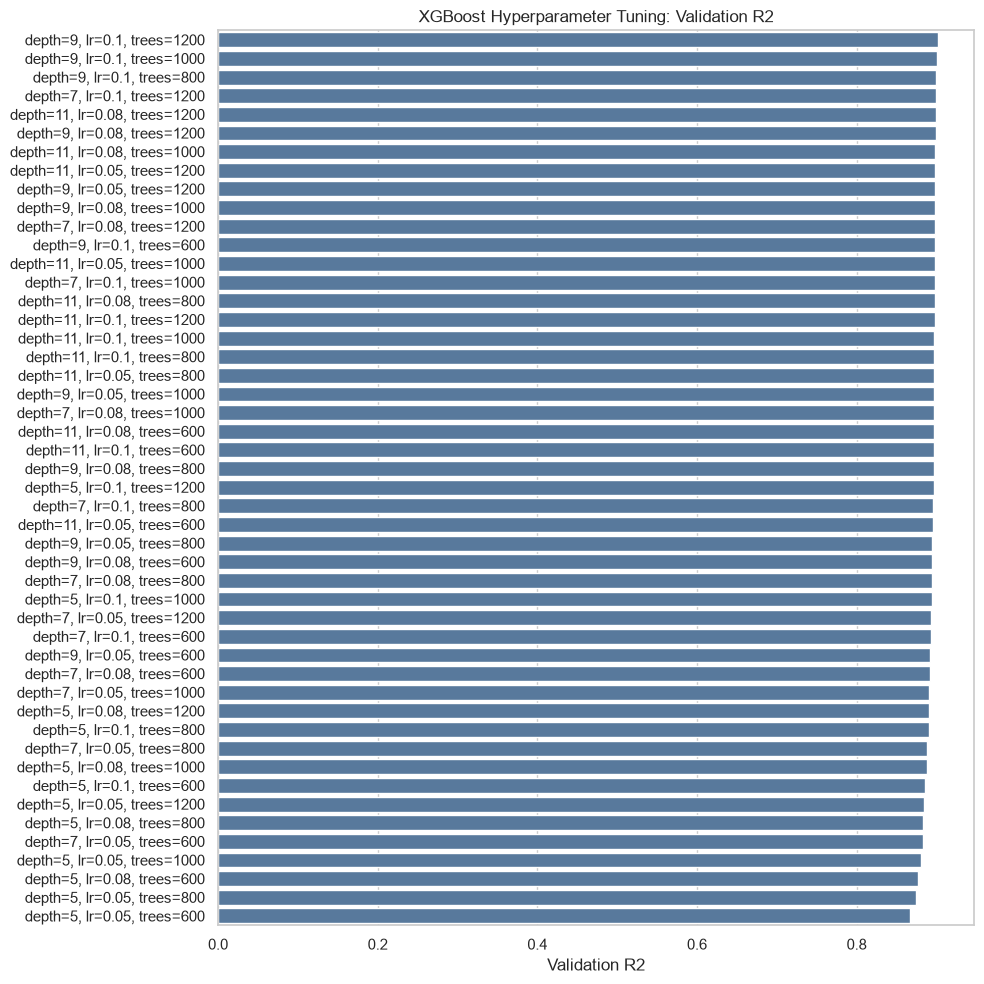

In [38]:
plot_df = tuning_results_df.copy()
plot_df["configuration_label"] = (
    "depth=" + plot_df["max_depth"].astype(str)
    + ", lr=" + plot_df["learning_rate"].astype(str)
    + ", trees=" + plot_df["n_estimators"].astype(str)
)

plt.figure(figsize=(10, 10))
sns.barplot(
    data=plot_df.sort_values("validation_r2", ascending=False),
    x="validation_r2",
    y="configuration_label",
    color="#4c78a8",
)
plt.title("XGBoost Hyperparameter Tuning: Validation R2")
plt.xlabel("Validation R2")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 8. Historical Stability Check

Use the selected target transform and best May-validation hyperparameters on earlier cutoffs. May 2026 is excluded here because it was used for feature-set selection and hyperparameter tuning. The separate target comparison above evaluates raw and log1p across all five rolling folds.


In [39]:
stability_months = [
    month for month in historical_plan["eval_month"].astype(str).tolist()
    if month < VALIDATION_MONTH
]


def evaluate_xgboost_fold(eval_month, model_params):
    plan_row = historical_plan[historical_plan["eval_month"] == eval_month].iloc[0]
    train_raw, eval_raw = rows_for_plan(plan_row, engineered_df)
    train_df, eval_df, bound_info = apply_train_price_bounds(train_raw, eval_raw)

    model = build_xgboost_pipeline(model_params)
    start_time = time.perf_counter()
    fit_xgboost_model(model, train_df[feature_cols], train_df[TARGET], TARGET_TRANSFORM)
    fit_seconds = time.perf_counter() - start_time

    train_predictions = predict_xgboost_model(model, train_df[feature_cols], TARGET_TRANSFORM)
    eval_predictions = predict_xgboost_model(model, eval_df[feature_cols], TARGET_TRANSFORM)
    train_metrics = regression_metrics(train_df[TARGET], train_predictions)
    eval_metrics = regression_metrics(eval_df[TARGET], eval_predictions)

    return {
        "model": "XGBoost",
        "configuration": "tuned",
        "feature_set": FEATURE_SET_NAME,
        "target_transform": TARGET_TRANSFORM,
        "eval_month": eval_month,
        "train_month_start": plan_row["train_month_start"],
        "train_month_end": plan_row["train_month_end"],
        **model_params,
        **bound_info,
        "fit_seconds": fit_seconds,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "validation_r2": eval_metrics["r2"],
        "validation_mae": eval_metrics["mae"],
        "validation_rmse": eval_metrics["rmse"],
        "validation_mape": eval_metrics["mape"],
        "validation_mdape": eval_metrics["mdape"],
    }

historical_results = pd.DataFrame(
    evaluate_xgboost_fold(eval_month, best_params)
    for eval_month in stability_months
)
historical_results["train_validation_r2_gap"] = historical_results["train_r2"] - historical_results["validation_r2"]
historical_results.to_csv(OUTPUT_DIR / "xgboost_historical_results.csv", index=False)
display(historical_results.round(4))

historical_summary = pd.DataFrame([{
    "model": "XGBoost",
    "configuration": "tuned",
    "feature_set": FEATURE_SET_NAME,
    "target_transform": TARGET_TRANSFORM,
    "n_cutoffs": historical_results["eval_month"].nunique(),
    "mean_validation_r2": historical_results["validation_r2"].mean(),
    "std_validation_r2": historical_results["validation_r2"].std(),
    "min_validation_r2": historical_results["validation_r2"].min(),
    "max_validation_r2": historical_results["validation_r2"].max(),
    "mean_validation_mae": historical_results["validation_mae"].mean(),
    "mean_validation_rmse": historical_results["validation_rmse"].mean(),
    "mean_validation_mape": historical_results["validation_mape"].mean(),
    "mean_validation_mdape": historical_results["validation_mdape"].mean(),
    "mean_train_validation_r2_gap": historical_results["train_validation_r2_gap"].mean(),
}])
historical_summary.to_csv(OUTPUT_DIR / "xgboost_historical_summary.csv", index=False)
display(historical_summary.round(4))

,model,configuration,feature_set,target_transform,eval_month,train_month_start,train_month_end,max_depth,learning_rate,n_estimators,price_lower_bound,price_upper_bound,price_per_sqft_lower_bound,price_per_sqft_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,train_rows_removed_by_price_filter,train_rows_removed_by_price_per_sqft_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,eval_rows_removed_by_price_filter,eval_rows_removed_by_price_per_sqft_filter,fit_seconds,train_r2,train_mae,validation_r2,validation_mae,validation_rmse,validation_mape,validation_mdape,train_validation_r2_gap
0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,log1p,2025-09,2024-09,2025-08,9,0.1,1200,195000.0,8500000.0,171.0440,1962.1664,130976,127817,1294,1865,11449,11172,102,175,7.1121,0.9730,85367.8286,0.9097,135756.0087,262529.7861,10.8870,7.5204,0.0633
1,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,log1p,2025-11,2024-11,2025-10,9,0.1,1200,191430.0,8500000.0,170.0507,1955.4514,131211,128079,1292,1840,9720,9464,111,145,6.7154,0.9724,85889.0348,0.9154,136738.9510,262013.1786,10.8076,7.6031,0.0570
2,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,log1p,2026-01,2025-01,2025-12,9,0.1,1200,190000.0,8588500.0,168.7560,1944.9444,130093,127001,1301,1791,7485,7290,95,100,7.1196,0.9731,85045.6342,0.8999,140257.5344,284092.4111,11.3676,7.7106,0.0732
3,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,log1p,2026-03,2025-03,2026-02,9,0.1,1200,188345.0,8650000.0,168.2467,1943.1577,129139,126081,1291,1767,11169,10877,135,157,7.3031,0.9730,84596.8295,0.9083,141580.0604,274919.6455,10.7070,7.5815,0.0647


,model,configuration,feature_set,target_transform,n_cutoffs,mean_validation_r2,std_validation_r2,min_validation_r2,max_validation_r2,mean_validation_mae,mean_validation_rmse,mean_validation_mape,mean_validation_mdape,mean_train_validation_r2_gap
0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,log1p,4,0.9083,0.0064,0.8999,0.9154,138583.1386,270888.7553,10.9423,7.6039,0.0645


## 9. Final Test Evaluation

After selecting the feature set, target transform, and hyperparameters on validation data, train once on the full final training window and evaluate once on the June 2026 test set.


In [40]:
final_xgb_model = build_xgboost_pipeline(best_params)
start_time = time.perf_counter()
fit_xgboost_model(final_xgb_model, final_train_df[feature_cols], final_train_df[TARGET], TARGET_TRANSFORM)
final_fit_seconds = time.perf_counter() - start_time

final_train_predictions = predict_xgboost_model(final_xgb_model, final_train_df[feature_cols], TARGET_TRANSFORM)
final_test_predictions = predict_xgboost_model(final_xgb_model, final_test_df[feature_cols], TARGET_TRANSFORM)
final_train_metrics = regression_metrics(final_train_df[TARGET], final_train_predictions)
final_test_metrics = regression_metrics(final_test_df[TARGET], final_test_predictions)

final_xgb_result = pd.DataFrame([{
    "model": "XGBoost",
    "configuration": "tuned",
    "target_transform": TARGET_TRANSFORM,
    "feature_set": FEATURE_SET_NAME,
    "train_window_months": fixed_train_window_months,
    "final_train_month_start": final_plan["train_month_start"],
    "final_train_month_end": final_plan["train_month_end"],
    "test_month": final_plan["eval_month"],
    "n_raw_features": len(feature_cols),
    **best_params,
    **final_bound_info,
    "fit_seconds": final_fit_seconds,
    "train_r2": final_train_metrics["r2"],
    "train_mae": final_train_metrics["mae"],
    "test_r2": final_test_metrics["r2"],
    "test_mae": final_test_metrics["mae"],
    "test_rmse": final_test_metrics["rmse"],
    "test_mape": final_test_metrics["mape"],
    "test_mdape": final_test_metrics["mdape"],
    "model_path": str(MODEL_PATH.relative_to(PROJECT_ROOT)),
}])

final_xgb_result.to_csv(OUTPUT_DIR / "xgboost_final_test_results.csv", index=False)
display(final_xgb_result.T)

,0
model,XGBoost
configuration,tuned
target_transform,log1p
feature_set,Base + Structural Derived + UnifiedSchoolDistrict
train_window_months,12
final_train_month_start,2025-06
final_train_month_end,2026-05
test_month,2026-06
n_raw_features,54
max_depth,9


### 9.1 Final Test by Target Transform

Train final XGBoost models for both raw and log1p targets using the same selected feature set and hyperparameters. This keeps final row-level predictions available for detailed error analysis under both target versions.


In [41]:
final_target_rows = []
final_target_prediction_frames = []
final_models_by_target = {}

for target_transform in TARGET_TRANSFORM_CANDIDATES:
    print(f"Final test by target transform: {target_transform}")
    model = build_xgboost_pipeline(best_params)

    start_time = time.perf_counter()
    fit_xgboost_model(model, final_train_df[feature_cols], final_train_df[TARGET], target_transform)
    fit_seconds = time.perf_counter() - start_time

    train_predictions = predict_xgboost_model(model, final_train_df[feature_cols], target_transform)
    test_predictions = predict_xgboost_model(model, final_test_df[feature_cols], target_transform)
    train_metrics = regression_metrics(final_train_df[TARGET], train_predictions)
    test_metrics = regression_metrics(final_test_df[TARGET], test_predictions)

    final_models_by_target[target_transform] = model
    final_target_rows.append({
        "model": "XGBoost",
        "configuration": "tuned_same_params_by_target",
        "target_transform": target_transform,
        "selected_target_transform": TARGET_TRANSFORM,
        "feature_set": FEATURE_SET_NAME,
        "train_window_months": fixed_train_window_months,
        "final_train_month_start": final_plan["train_month_start"],
        "final_train_month_end": final_plan["train_month_end"],
        "test_month": final_plan["eval_month"],
        "n_raw_features": len(feature_cols),
        **best_params,
        **final_bound_info,
        "fit_seconds": fit_seconds,
        "train_r2": train_metrics["r2"],
        "train_mae": train_metrics["mae"],
        "test_r2": test_metrics["r2"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
        "test_mape": test_metrics["mape"],
        "test_mdape": test_metrics["mdape"],
    })

    prediction_frame = final_test_df[[
        "ListingKey",
        "CloseDate",
        "close_month",
        "CountyOrParish",
        TARGET,
    ]].copy()
    prediction_frame["model"] = "XGBoost"
    prediction_frame["configuration"] = "tuned_same_params_by_target"
    prediction_frame["feature_set"] = FEATURE_SET_NAME
    prediction_frame["target_transform"] = target_transform
    prediction_frame["selected_target_transform"] = TARGET_TRANSFORM
    prediction_frame["predicted_ClosePrice"] = test_predictions
    prediction_frame["residual"] = prediction_frame[TARGET] - prediction_frame["predicted_ClosePrice"]
    prediction_frame["absolute_error"] = prediction_frame["residual"].abs()
    prediction_frame["absolute_percentage_error"] = prediction_frame["absolute_error"] / prediction_frame[TARGET] * 100
    final_target_prediction_frames.append(prediction_frame)

final_target_results_df = pd.DataFrame(final_target_rows).sort_values(
    ["test_mdape", "test_r2"],
    ascending=[True, False],
).reset_index(drop=True)
final_target_predictions_df = pd.concat(final_target_prediction_frames, ignore_index=True)

final_target_results_df.to_csv(OUTPUT_DIR / "xgboost_final_test_results_by_target.csv", index=False)
final_target_predictions_df.to_csv(OUTPUT_DIR / "test_predictions_xgboost_by_target.csv", index=False)

for target_transform, pred_df in final_target_predictions_df.groupby("target_transform"):
    pred_df.to_csv(OUTPUT_DIR / f"test_predictions_xgboost_{target_transform}.csv", index=False)

display(final_target_results_df.round(4))
display(final_target_predictions_df.head())


Final test by target transform: raw
Final test by target transform: log1p


,model,configuration,target_transform,selected_target_transform,feature_set,train_window_months,final_train_month_start,final_train_month_end,test_month,n_raw_features,max_depth,learning_rate,n_estimators,price_lower_bound,price_upper_bound,price_per_sqft_lower_bound,price_per_sqft_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,train_rows_removed_by_price_filter,train_rows_removed_by_price_per_sqft_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,eval_rows_removed_by_price_filter,eval_rows_removed_by_price_per_sqft_filter,fit_seconds,train_r2,train_mae,test_r2,test_mae,test_rmse,test_mape,test_mdape
0,XGBoost,tuned_same_params_by_target,log1p,log1p,Base + Structural Derived + UnifiedSchoolDistrict,12,2025-06,2026-05,2026-06,54,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,1294,1773,12858,12538,139,181,6.8447,0.9719,86159.8675,0.9087,148075.0993,289276.1337,10.8434,7.6545
1,XGBoost,tuned_same_params_by_target,raw,log1p,Base + Structural Derived + UnifiedSchoolDistrict,12,2025-06,2026-05,2026-06,54,9,0.1,1200,188282.5,9000000.0,167.9046,1960.6069,130114,127047,1294,1773,12858,12538,139,181,6.8461,0.9801,83737.1622,0.9081,152226.5923,290186.2529,11.6870,8.1097


,ListingKey,CloseDate,close_month,CountyOrParish,ClosePrice,model,configuration,feature_set,target_transform,selected_target_transform,predicted_ClosePrice,residual,absolute_error,absolute_percentage_error
0,1035814040,2026-06-11,2026-06,Alameda,595000.0,XGBoost,tuned_same_params_by_target,Base + Structural Derived + UnifiedSchoolDistrict,raw,log1p,1.021682e+06,-4.266822e+05,4.266822e+05,71.711292
1,1076795790,2026-06-25,2026-06,San Bernardino,865000.0,XGBoost,tuned_same_params_by_target,Base + Structural Derived + UnifiedSchoolDistrict,raw,log1p,7.121312e+05,1.528688e+05,1.528688e+05,17.672688
2,1082181091,2026-06-15,2026-06,San Diego,1675835.0,XGBoost,tuned_same_params_by_target,Base + Structural Derived + UnifiedSchoolDistrict,raw,log1p,1.431252e+06,2.445829e+05,2.445829e+05,14.594687
3,1084829231,2026-06-30,2026-06,San Diego,1589308.0,XGBoost,tuned_same_params_by_target,Base + Structural Derived + UnifiedSchoolDistrict,raw,log1p,1.452776e+06,1.365315e+05,1.365315e+05,8.590626
4,1090181279,2026-06-16,2026-06,San Mateo,3695000.0,XGBoost,tuned_same_params_by_target,Base + Structural Derived + UnifiedSchoolDistrict,raw,log1p,4.766542e+06,-1.071542e+06,1.071542e+06,28.999770


## 10. Model Comparison

Compare against existing Week 6 model results. The Week 6 table includes each prior model's selected Week 6 feature set; the `feature_set` and `target_transform` columns make modeling differences explicit. The by-target final table keeps raw and log1p XGBoost results available for comparison and error analysis.


In [42]:
week6_results_path = PROJECT_ROOT / "outputs" / "week6_feature_engineering" / "final_base_vs_selected_feature_results.csv"
if not week6_results_path.exists():
    raise FileNotFoundError(f"Missing Week 6 comparison results: {week6_results_path}")

week6_results = pd.read_csv(week6_results_path)
week6_selected_results = week6_results[week6_results["evaluation_role"] == "Selected New"].copy()
week6_selected_results["configuration"] = "week6_selected"
week6_selected_results["target_transform"] = "raw"

comparison_columns = [
    "model",
    "configuration",
    "target_transform",
    "feature_set",
    "test_r2",
    "test_mae",
    "test_rmse",
    "test_mape",
    "test_mdape",
    "train_r2",
]

comparison_df = pd.concat([
    week6_selected_results[comparison_columns],
    final_xgb_result[comparison_columns + ["fit_seconds"]],
], ignore_index=True, sort=False)
comparison_df = comparison_df.sort_values("test_r2", ascending=False)
comparison_df.to_csv(OUTPUT_DIR / "xgboost_model_comparison.csv", index=False)
display(comparison_df.round(4))

,model,configuration,target_transform,feature_set,test_r2,test_mae,test_rmse,test_mape,test_mdape,train_r2,fit_seconds
3,XGBoost,tuned,log1p,Base + Structural Derived + UnifiedSchoolDistrict,0.9087,148075.0993,289276.1337,10.8434,7.6545,0.9719,6.9299
2,RandomForestRegressor,week6_selected,raw,Base + UnifiedSchoolDistrict,0.8901,157781.2308,317251.0829,11.6415,7.6041,0.9850,NaN
1,LinearRegression,week6_selected,raw,Base + Structural Derived + UnifiedSchoolDistrict,0.8552,215528.1873,364204.4819,19.5947,14.3444,0.8551,NaN
0,DecisionTreeRegressor,week6_selected,raw,Base + UnifiedSchoolDistrict,0.7641,226461.2179,464915.6746,16.3086,10.8435,1.0000,NaN


## 11. Prediction Diagnostics and Feature Importance

Save row-level predictions, inspect actual-vs-predicted behavior, and review XGBoost feature importances. Feature importance is treated as a model diagnostic only, not causal evidence.


In [43]:
test_predictions_df = final_test_df[[
    "ListingKey",
    "CloseDate",
    "close_month",
    "CountyOrParish",
    TARGET,
]].copy()
test_predictions_df["model"] = "XGBoost"
test_predictions_df["configuration"] = "tuned"
test_predictions_df["feature_set"] = FEATURE_SET_NAME
test_predictions_df["target_transform"] = TARGET_TRANSFORM
test_predictions_df["predicted_ClosePrice"] = final_test_predictions
test_predictions_df["residual"] = test_predictions_df[TARGET] - test_predictions_df["predicted_ClosePrice"]
test_predictions_df["absolute_error"] = test_predictions_df["residual"].abs()
test_predictions_df["absolute_percentage_error"] = test_predictions_df["absolute_error"] / test_predictions_df[TARGET] * 100

test_predictions_df.to_csv(OUTPUT_DIR / "test_predictions_xgboost.csv", index=False)
display(test_predictions_df.head())

,ListingKey,CloseDate,close_month,CountyOrParish,ClosePrice,model,configuration,feature_set,target_transform,predicted_ClosePrice,residual,absolute_error,absolute_percentage_error
1,1035814040,2026-06-11,2026-06,Alameda,595000.0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,log1p,8.604054e+05,-265405.4375,265405.4375,44.605956
3,1076795790,2026-06-25,2026-06,San Bernardino,865000.0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,log1p,7.049464e+05,160053.5625,160053.5625,18.503302
6,1082181091,2026-06-15,2026-06,San Diego,1675835.0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,log1p,1.502919e+06,172916.0000,172916.0000,10.318200
7,1084829231,2026-06-30,2026-06,San Diego,1589308.0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,log1p,1.486199e+06,103109.3750,103109.3750,6.487690
8,1090181279,2026-06-16,2026-06,San Mateo,3695000.0,XGBoost,tuned,Base + Structural Derived + UnifiedSchoolDistrict,log1p,3.913295e+06,-218295.2500,218295.2500,5.907855


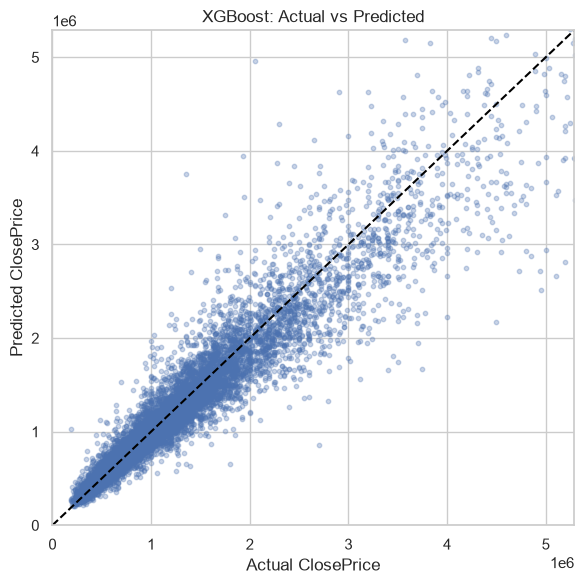

In [44]:
plt.figure(figsize=(6, 6))
max_price = np.nanpercentile(final_test_df[TARGET], 99)
plt.scatter(final_test_df[TARGET], final_test_predictions, s=10, alpha=0.3)
plt.plot([0, max_price], [0, max_price], linestyle="--", color="black")
plt.xlim(0, max_price)
plt.ylim(0, max_price)
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("XGBoost: Actual vs Predicted")
plt.tight_layout()
plt.show()

,feature,importance
2029,regular_cat__CountyOrParish_San Diego,0.241435
2028,regular_cat__CountyOrParish_San Bernardino,0.078244
2025,regular_cat__CountyOrParish_Riverside,0.072163
2007,regular_cat__CountyOrParish_Kern,0.027615
2021,regular_cat__CountyOrParish_Orange,0.018094
2032,regular_cat__CountyOrParish_San Luis Obispo,0.011648
2016,regular_cat__CountyOrParish_Merced,0.009325
306,high_cat__City_Oakland,0.007215
2035,regular_cat__CountyOrParish_Santa Clara,0.005803
322,high_cat__City_Palm Springs,0.005430


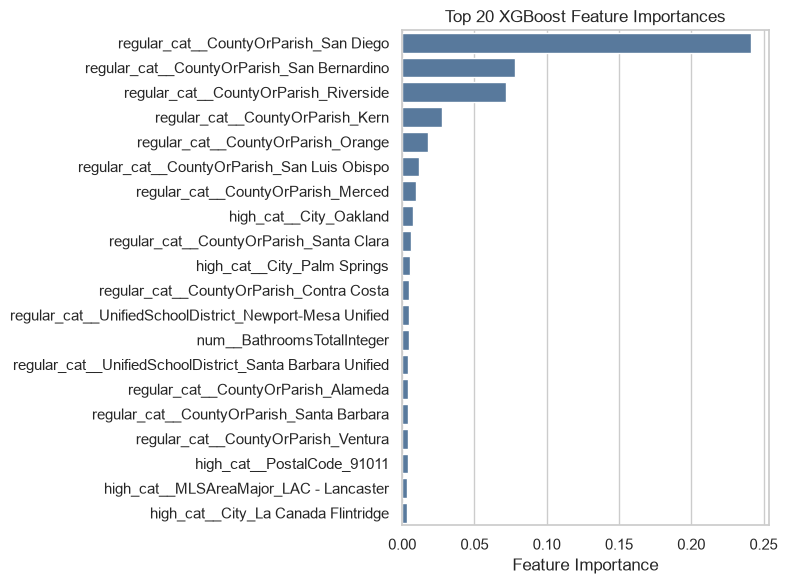

In [45]:
preprocessor = final_xgb_model.named_steps["preprocess"]
xgb_estimator = final_xgb_model.named_steps["model"]

try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = np.array([f"feature_{idx}" for idx in range(len(xgb_estimator.feature_importances_))])

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": xgb_estimator.feature_importances_,
    })
    .sort_values("importance", ascending=False)
)
importance_df.to_csv(OUTPUT_DIR / "xgboost_feature_importances.csv", index=False)
display(importance_df.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(20), x="importance", y="feature", color="#4c78a8")
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [46]:
joblib.dump(
    {
        "model": final_xgb_model,
        "feature_set": FEATURE_SET_NAME,
        "feature_cols": feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "boolean_cols": boolean_cols,
        "flag_cols": flag_cols,
        "target": TARGET,
        "target_transform": TARGET_TRANSFORM,
        "best_params": best_params,
        "outlier_filter_bounds": final_bound_info,
        "validation_month": VALIDATION_MONTH,
        "test_month": str(final_plan["eval_month"]),
        "xgboost_version": xgb.__version__,
    },
    MODEL_PATH,
)

print("Saved model:", MODEL_PATH)

Saved model: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/models/week7_advanced_models/xgboost_tuned_pipeline.joblib


## 12. Summary

- Compared two XGBoost feature-set candidates on the May 2026 validation month. `Base + Structural Derived + UnifiedSchoolDistrict` was selected with 54 raw features because it had slightly better validation R² (`0.8740`) and MdAPE (`11.71%`) than the smaller school-district-only candidate.
- Compared raw `ClosePrice` and `log1p(ClosePrice)` across all five rolling validation folds using default XGBoost under the selected feature set.
- The raw target had slightly higher mean validation R² (`0.8796` vs. `0.8764`) and lower RMSE, but `log1p` had lower MAE (`$172,143` vs. `$182,149`), lower MAPE (`13.62%` vs. `15.79%`), lower MdAPE (`9.93%` vs. `11.51%`), and a smaller train-validation R² gap (`0.0236` vs. `0.0375`). Because the selection criterion prioritized MdAPE and percentage-error stability, `log1p` was selected.
- Tuned `max_depth`, `learning_rate`, and `n_estimators` on the May 2026 validation month using the selected `log1p` target. The best configuration was `max_depth = 9`, `learning_rate = 0.10`, and `n_estimators = 1200`, with validation R² `0.9019`, validation MAE `$150,470`, and validation MdAPE `7.74%`.
- Historical stability across the four earlier cutoffs was strong: mean validation R² `0.9083`, standard deviation `0.0064`, mean MAE `$138,583`, and mean MdAPE `7.60%`.
- Final June 2026 test metrics for tuned XGBoost with `log1p` target were test R² `0.9087`, MAE `$148,075`, RMSE `$289,276`, MAPE `10.84%`, and MdAPE `7.65%`.
- Under the same final hyperparameters, the raw target had slightly lower R² and higher error metrics than `log1p` on the final test set. This supports using `log1p` for the final model.
- Compared with the Week 6 selected models, tuned XGBoost had the best final test R², MAE, RMSE, and MAPE: R² `0.9087` vs. Random Forest `0.8901`, Linear Regression `0.8552`, and Decision Tree `0.7641`. Random Forest still had a very small MdAPE edge (`7.60%` vs. XGBoost `7.65%`).
- XGBoost still has some overfitting risk because train R² (`0.9719`) is higher than test R² (`0.9087`). However, it improved the main final-test metrics overall and reduced MAE/RMSE relative to the Week 6 models.
- Top feature importances were mostly location-related, especially county indicators for San Diego, San Bernardino, Riverside, Kern, and Orange, with some city, postal code, and school district signals. These importances are useful diagnostics, but they should not be interpreted as causal effects.
- Detailed segment-level error analysis is handled separately in `06_evaluation.ipynb` for the Week 8 deliverable.
